# 4. Evaluation Metrics for Classification

In the previous session we trained a model for predicting churn. How do we know if it's good?

# 4.1 Evaluation metrics: session overview
- Dataset: [Kaggle](https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv)
- Metric - function that compares the predictions with the actual values and outputs a single number that tells how good the predictions are

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer

In [88]:
# Paths
base_path = Path.cwd()
file_path = base_path / "data" / "data.csv"
df = pd.read_csv(file_path)

In [89]:
# replacing column names with lower caps and spaces with underscore in the column name
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

Column `totalcharges` should be integer.

In [90]:
df.totalcharges

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: totalcharges, Length: 7043, dtype: str

In [91]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [92]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [93]:
df.totalcharges = df.totalcharges.fillna(0)

In [94]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


### Target variable converted to `integer`

In [95]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [96]:
df.churn = (df.churn == 'yes').astype(int)

In [97]:
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

# Setting up the validation framework

<div style="margin-left: 0; text-align: left; font-family: Arial, sans-serif;">

<h3>Dataset Split Workflow</h3>

<div style="display: flex; width: 720px; border: 2px solid black; height: 70px; margin-bottom: 20px;">
  <div style="width: 60%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 20%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>VAL (20%)</b>
  </div>
  <div style="width: 20%; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 1:</b> Split dataset into Train / Validation / Test</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; align-items: center; gap: 20px; margin-bottom: 20px;">
  <div style="width: 576px; border: 2px solid #1f77b4; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>FULL TRAIN = TRAIN + VAL (80%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 2:</b> After tuning on validation, merge Train + Validation into Full Train</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; gap: 20px; margin-bottom: 20px;">
  <div style="width: 432px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>VAL (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Inside Full Train:</b> Validation is <b>20% / 80% = 25%</b> of Full Train</p>

<hr style="margin: 20px 0;">

<p style="font-size: 16px;">
<b>Workflow:</b><br>
1. Train on <b>Train</b><br>
2. Tune on <b>Validation</b><br>
3. Retrain final model on <b>Full Train = Train + Validation</b><br>
4. Evaluate once on <b>Test</b>
</p>

</div>

- Perform the train/validation/test split with Scikit-Learn

In [98]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [99]:
assert len(df) == (len(df_train) + len(df_val) + len(df_test))

In [100]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [101]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [102]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

# EDA
- Check missing values
- Look at the target variable (churn)
- Look at numerical and categorical variables

In [103]:
df_full_train = df_full_train.reset_index(drop=True)

In [104]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [105]:
df_full_train.churn.value_counts(normalize=True) # as a percentage of the total

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [106]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [107]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [108]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [109]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

# Feature importance: Mutual information (categorical variables)
Mutual information - concept from information theory, it tells us how much we can learn about one variable if we know the value of another

 - https://en.wikipedia.org/wiki/Mutual_information

In [110]:
df_full_train.dtypes[df_full_train.dtypes == 'str'].index

Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod'],
      dtype='str')

In [111]:
mutual_info_score(df_full_train.churn, df_full_train.contract) # contract is informative

0.0983203874041556

In [112]:
mutual_info_score(df_full_train.gender, df_full_train.churn) # gender is less informative

0.0001174846211139946

In [113]:
mutual_info_score(df_full_train.partner, df_full_train.churn) # more important than gender, more info score

0.009967689095399745

In [114]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [115]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

# Feature importance: Correlation
How about numerical columns?

- Correlation coefficient - https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

### Interpretation of Tenure vs Churn

The boxplot shows a clear separation between customers who churned and those who did not:

- Customers with **churn = 1** generally have **lower tenure**
- Customers with **churn = 0** generally have **higher tenure**
- The median tenure for non-churned customers is much higher than for churned customers

This suggests that **customers who stay longer are less likely to churn**, making **tenure** an important predictive feature for the churn model.

There is still some overlap between the two groups, so tenure alone does not fully explain churn, but it appears to be a **strong indicator**.

In [116]:
df_full_train[numerical].corrwith(df_full_train.churn) # negative tenure corr confirms the above box plots

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

### Tenure

<Axes: xlabel='churn', ylabel='tenure'>

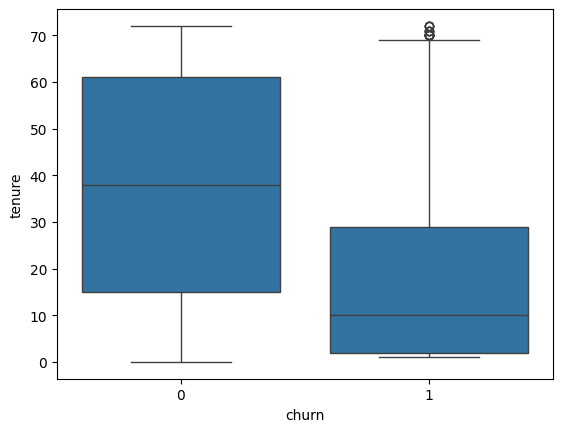

In [117]:
sns.boxplot(x='churn', y='tenure', data=df_full_train)

Negative correlation

In [118]:
df_full_train[df_full_train.tenure <= 2].churn.mean() # less than 2 months

np.float64(0.5953420669577875)

In [119]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean() # btwn 2-12months

np.float64(0.3994413407821229)

In [120]:
df_full_train[df_full_train.tenure > 12].churn.mean() # more than a year

np.float64(0.17634908339788277)

### Monthly Charges

<Axes: xlabel='churn', ylabel='monthlycharges'>

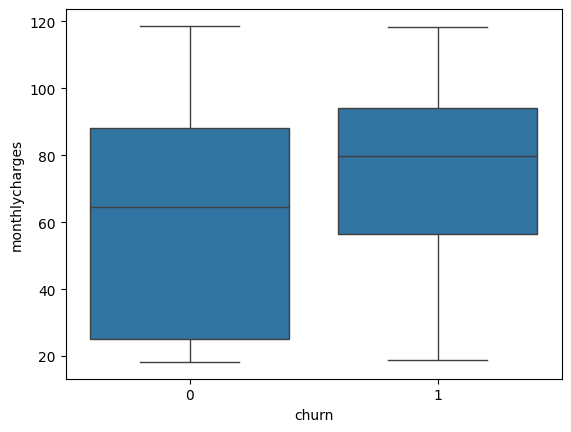

In [121]:
sns.boxplot(x='churn', y='monthlycharges', data=df_full_train)

Positive correlation

In [122]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [123]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [124]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

## One-Hot Encoding

One-hot encoding converts a categorical feature into multiple binary columns.

### Example: `contract`

```mermaid
flowchart LR
    A["contract = 'month-to-month'"] --> B["contract_month_to_month = 1"]
    A --> C["contract_one_year = 0"]
    A --> D["contract_two_year = 0"]
```

### Encoded Representation

| Original Value | contract_month_to_month | contract_one_year | contract_two_year |
|:--|--:|--:|--:|
| `month-to-month` | 1 | 0 | 0 |

### General Rule

For a categorical feature with possible values:

- `month-to-month`
- `one_year`
- `two_year`

we create:

- `contract_month_to_month`
- `contract_one_year`
- `contract_two_year`

Each row gets:

- **1** for the matching category
- **0** for all others

### Transform all the variables

In [125]:
dv = DictVectorizer(sparse=False) # sparse set to false to use np array matrix
train_dict = df_train[categorical + numerical].to_dict(orient='records') 
X_train = dv.fit_transform(train_dict) # does the fit then tranformation at once instead of 2 steps


val_dict = df_val[categorical + numerical].to_dict(orient='records')

# why tranform only, validation/test must use the same feature columns learned from train. 
# which is already fitted
X_val = dv.transform(val_dict) 

X_train.shape

(4225, 45)

## 3.9 Logistic Regression 

- Binary classification
- Linear vs logistic regression

Logistic Regression is a **binary classification** algorithm used to predict the probability of an event, such as **churn = 1** or **churn = 0**.

### 1. Linear Score

First, we compute a linear combination of the features:

$
z = w_0 + x_1 w_1 + x_2 w_2 + \dots + x_n w_n
$

or in vector form:

$
z = w_0 + x^T w
$

### 2. Sigmoid Function

The linear score is then passed through the **sigmoid** function to convert it into a probability between 0 and 1:

$
g(z) = \frac{1}{1 + e^{-z}}
$

```text
Probability
1.0 |                           ********
    |                       ****
    |                    ***
0.5 |------------------***------------------> z
    |               ***
    |           ****
0.0 |***********
```

- When $z \ll 0$, then $\hat{y} \approx 0$
- When $z = 0$, then $\hat{y} = 0.5$
- When $z \gg 0$, then $\hat{y} \approx 1$



### 3. Predicted Probability

The predicted probability of the positive class is:

$
\hat{y} = g(z)
$

So:

$
\hat{y} = \frac{1}{1 + e^{-(w_0 + x^T w)}}
$

### 4. Decision Rule

To convert probability into a class prediction:

- If $\hat{y} \geq 0.5$ → predict **1**
- If $\hat{y} < 0.5$ → predict **0**

### 5. Interpretation

- Output is a **probability**
- Useful for **binary outcomes**
- In churn prediction:
  - $\hat{y}$ close to **1** → customer is more likely to churn
  - $\hat{y}$ close to **0** → customer is less likely to churn

```mermaid
flowchart LR
    A[Input Features x] --> B["Linear Score: z = w0 + x^T w"]
    B --> C["Sigmoid: g(z) = 1 / (1 + e^(-z))"]
    C --> D["Predicted Probability: y_hat"]
    D --> E{Threshold 0.5}
    E -->|>= 0.5| F[Predict Churn = 1]
    E -->|< 0.5| G[Predict Churn = 0]
```

# 3.10 Training logistic regression with Scikit-Learn
- Train a model with Scikit-Learn
- Apply it to the validation dataset
- Calculate the accuracy

In [126]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\alann\anaconda3\envs\ml-zoomcamp-churn\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [127]:
model.intercept_[0]

np.float64(-0.10910575411731115)

In [128]:
model.coef_[0].round(3) # weights w

array([ 0.476, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.336,  0.317, -0.089,  0.004, -0.258,  0.142,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.059, -0.087, -0.032,  0.07 , -0.059,  0.142,
       -0.25 ,  0.216, -0.121, -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [129]:
model.predict(X_train) # result is binary(1s & 0s) as expected

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [130]:
model.predict_proba(X_train) # probability scores of R(YES) and LEFT(NO)

array([[0.90452492, 0.09547508],
       [0.32058285, 0.67941715],
       [0.36630247, 0.63369753],
       ...,
       [0.46766799, 0.53233201],
       [0.95761329, 0.04238671],
       [0.3012034 , 0.6987966 ]], shape=(4225, 2))

In [131]:
model.predict_proba(X_train)[:, 1] # only interested in the 2nd column, RHS (YES)

array([0.09547508, 0.67941715, 0.63369753, ..., 0.53233201, 0.04238671,
       0.6987966 ], shape=(4225,))

In [132]:
y_pred = model.predict_proba(X_val)[:, 1]

In [133]:
y_pred

array([0.00896799, 0.20454216, 0.21215178, ..., 0.1363222 , 0.79995367,
       0.83758207], shape=(1409,))

In [134]:
churn_decision = (y_pred >= 0.5) # decison threshold, recap decision rule in sigmoid function

In [135]:
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [136]:
df_val[churn_decision].customerid # people who will receive promotional email

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 312, dtype: str

In [137]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [138]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [139]:
(y_val == churn_decision).mean() # comparison of predicted vs actual

np.float64(0.8026969481902059)

# 4.2 Accuracy and dummy model
- Evaluate the model on different thresholds
- Check the accuracy of dummy baselines

**Accuracy** measures how often the logistic regression model predicts the correct class.

### Formula

$
\large \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$

or

$
\large \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$

---

## In Logistic Regression

Logistic regression first predicts a **probability**:

$
\large \hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}
$

where:

$
\large z = w_0 + w_1x_1 + w_2x_2 + \cdots + w_nx_n
$

Then convert probability to a class label using a threshold (usually **0.5**):

- If $\hat{p} \geq 0.5$ → predict **1**
- If $\hat{p} < 0.5$ → predict **0**

---

In [140]:
len(y_val)

1409

In [141]:
(y_val == churn_decision).sum()

np.int64(1131)

In [142]:
1131 / 1409 # same as (y_val == churn_decision).mean()

0.8026969481902059

## Determining suitable threshhold

In [154]:
accuracy_score(y_val, y_pred >= 0.5)

0.8026969481902059

In [151]:
thresholds = np.linspace(0, 1, 21)
scores = []
for t in thresholds:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).mean()
    print(f"{t:.2f}: {score:.3f}")
    scores.append(score)

0.00: 0.274
0.05: 0.510
0.10: 0.592
0.15: 0.667
0.20: 0.710
0.25: 0.739
0.30: 0.760
0.35: 0.772
0.40: 0.785
0.45: 0.794
0.50: 0.803
0.55: 0.801
0.60: 0.796
0.65: 0.786
0.70: 0.766
0.75: 0.744
0.80: 0.734
0.85: 0.726
0.90: 0.726
0.95: 0.726
1.00: 0.726


In [152]:
from sklearn.metrics import accuracy_score

In [157]:
# calculation with the method
thresholds = np.linspace(0, 1, 21)
scores = []
for t in thresholds:
    score = accuracy_score(y_val, y_pred >= 0.5)
    print(f"{t:.2f}: {score:.3f}")
    scores.append(score)

0.00: 0.803
0.05: 0.803
0.10: 0.803
0.15: 0.803
0.20: 0.803
0.25: 0.803
0.30: 0.803
0.35: 0.803
0.40: 0.803
0.45: 0.803
0.50: 0.803
0.55: 0.803
0.60: 0.803
0.65: 0.803
0.70: 0.803
0.75: 0.803
0.80: 0.803
0.85: 0.803
0.90: 0.803
0.95: 0.803
1.00: 0.803


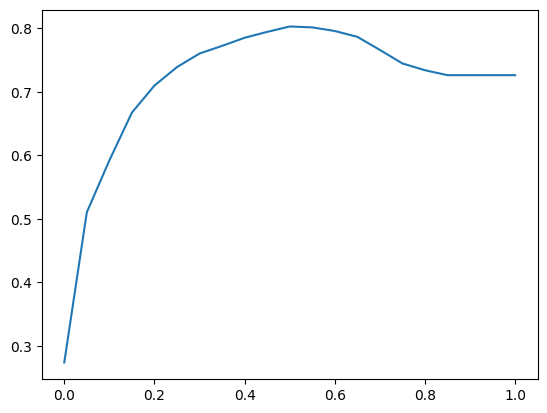

In [148]:
plt.plot(thresholds, scores)

In [160]:
from collections import Counter

In [161]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

## Logistic Regression and Class Imbalance

In churn prediction, the target classes are often **imbalanced**:

- **73%** of customers do **not churn** (`0`)
- **27%** of customers **churn** (`1`)

This means the model sees **many more negative examples than positive ones**.

---

## Why class imbalance matters

A very simple **dummy model** could predict:

- always predict **0** (no churn)

Then it would still achieve:

$
\large \text{Accuracy} = 73\%
$

even though it **never detects churners**.

So if our logistic regression gets:

$
\large 80\%
$

accuracy, the real improvement is only:

$
\large 80\% - 73\% = 7\%
$

---

## Key idea

Because the dataset is imbalanced:

- **Accuracy alone can be misleading**
- A model may look good simply by predicting the majority class
- We must compare logistic regression against a **baseline / dummy model**

---

## Better metrics for imbalanced classification

In addition to accuracy, use:

- **Precision**
- **Recall**
- **F1-score**
- **ROC AUC**

These help evaluate how well the model identifies the **minority class** (churners).

---

## Interpretation in churn prediction

- Majority class = **No Churn (0)**
- Minority class = **Churn (1)**

A good logistic regression model should not only improve overall accuracy, but also:

- correctly identify **actual churners**
- avoid simply predicting **everyone stays**

---

## Quick visual intuition

```text
Actual distribution:
[ No Churn, No Churn, No Churn, Churn, Churn, No Churn ]
      73% stay                    27% churn

Dummy model prediction:
[ No Churn, No Churn, No Churn, No Churn, No Churn, No Churn ]

Accuracy looks high (73%)
But churn detection is poor

In [166]:
Counter(y_val) # more none churning customers

Counter({np.int64(0): 1023, np.int64(1): 386})

In [165]:
1 - y_val.mean() # 73% non churning customers

np.float64(0.7260468417317246)

# 4.3 Confusion Matrix
- Different types of errors and correct decisions
- Arranging them in a table


A **confusion matrix** shows how the logistic regression predictions compare to the actual class labels.

It helps us see:

- what the model got **right**
- what the model got **wrong**
- how well it detects the **positive class** (e.g. churn)

---

## 1. Confusion Matrix Layout

| Actual \\ Predicted | Predict 0 (No Churn) | Predict 1 (Churn) |
|:--|--:|--:|
| **Actual 0 (No Churn)** | **TN** (True Negative) | **FP** (False Positive) |
| **Actual 1 (Churn)** | **FN** (False Negative) | **TP** (True Positive) |

---

## 2. Meaning of Each Outcome

- **TN** → predicted **No Churn**, and customer actually **did not churn**
- **FP** → predicted **Churn**, but customer actually **did not churn**
- **FN** → predicted **No Churn**, but customer actually **did churn**
- **TP** → predicted **Churn**, and customer actually **did churn**

---

## 3. Visual Intuition

```text
                    Predicted
                ┌───────────┬───────────┐
                │     0     │     1     │
┌───────────────┼───────────┼───────────┤
│ Actual 0      │    TN     │    FP     │
│ (No Churn)    │   Correct │   Wrong   │
├───────────────┼───────────┼───────────┤
│ Actual 1      │    FN     │    TP     │
│ (Churn)       │   Wrong   │  Correct  │
└───────────────┴───────────┴───────────┘